In [3]:
!pip install xgboost lightgbm optuna imbalanced-learn -q
print('All libraries installed!')

All libraries installed!


In [4]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings
warnings.filterwarnings('ignore')

# Core ML
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

# Boosting models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb

# Class imbalance
from imblearn.over_sampling import SMOTE

# Hyperparameter tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
print('All libraries imported successfully!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All libraries imported successfully!


In [5]:
PROJECT_FOLDER = '/content/drive/MyDrive/Capstone/Project'
DATASET_PATH   = os.path.join(PROJECT_FOLDER, 'preprocessed_data_rf.csv')

df = pd.read_csv(DATASET_PATH)
print(f'Loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'\nColumns: {list(df.columns)}')
df.head()

Loaded: 1999995 rows, 34 columns

Columns: ['cpu_usage', 'memory_usage', 'network_traffic', 'power_consumption', 'num_executed_instructions', 'execution_time', 'energy_efficiency', 'hour', 'dayofweek', 'dayofmonth', 'month', 'is_weekend', 'task_type_encoded', 'task_priority_encoded', 'task_status_encoded', 'memory_roll_mean_5', 'memory_roll_mean_10', 'memory_roll_std_5', 'memory_roll_max_5', 'cpu_roll_mean_5', 'cpu_roll_std_5', 'memory_lag_1', 'memory_lag_2', 'memory_lag_3', 'memory_lag_5', 'cpu_lag_1', 'cpu_lag_2', 'cpu_lag_3', 'memory_rate_of_change', 'memory_pct_change', 'cpu_rate_of_change', 'memory_cpu_product', 'memory_cpu_ratio', 'memory_spike']


,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,hour,dayofweek,dayofmonth,...,memory_lag_5,cpu_lag_1,cpu_lag_2,cpu_lag_3,memory_rate_of_change,memory_pct_change,cpu_rate_of_change,memory_cpu_product,memory_cpu_ratio,memory_spike
0,74.036326,82.890784,253.404369,63.456954,5002.0,42.161191,0.297407,0,6,1,...,49.976089,99.077509,93.148608,14.019569,0.000000,0.000000,0.000000,6136.929072,1.119596,1
1,89.889006,5.710089,453.161356,310.077375,8403.0,14.146201,0.862283,0,6,1,...,89.199261,74.036326,99.077509,93.148608,-77.180695,-0.931113,15.852680,513.274255,0.063524,0
2,50.054758,9.175866,3.881842,247.693806,6263.0,57.264987,0.875892,0,6,1,...,74.367251,89.889006,74.036326,99.077509,3.465777,0.606957,-39.834248,459.295770,0.183317,0
3,23.710173,49.976089,971.309008,114.507997,6029.0,21.798088,0.596863,0,6,1,...,68.979072,50.054758,89.889006,74.036326,40.800223,4.446471,-26.344585,1184.941732,2.107791,0
4,49.506011,86.686656,848.387377,39.412622,3845.0,8.481163,0.500369,0,6,1,...,71.444353,23.710173,50.054758,89.889006,36.710567,0.734563,25.795838,4291.510566,1.751033,1


In [6]:
EXCLUDE_COLS = [
    'memory_spike',
    'memory_usage',
    'memory_rate_of_change',
    'memory_pct_change',
    'memory_cpu_product',
    'memory_cpu_ratio'
]

feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS]

X_full = df[feature_cols].values
y_cls  = df['memory_spike'].values

print(f'Total samples  : {len(X_full)}')
print(f'Total features : {len(feature_cols)}')
print(f'\nFeature list:')
for i, f in enumerate(feature_cols, 1):
    print(f'  {i:2d}. {f}')

print(f'\nClass balance:')
print(f'  Normal (0) : {(y_cls==0).sum()}  ({(y_cls==0).mean()*100:.1f}%)')
print(f'  Spike  (1) : {(y_cls==1).sum()}  ({(y_cls==1).mean()*100:.1f}%)')

Total samples  : 1999995
Total features : 28

Feature list:
   1. cpu_usage
   2. network_traffic
   3. power_consumption
   4. num_executed_instructions
   5. execution_time
   6. energy_efficiency
   7. hour
   8. dayofweek
   9. dayofmonth
  10. month
  11. is_weekend
  12. task_type_encoded
  13. task_priority_encoded
  14. task_status_encoded
  15. memory_roll_mean_5
  16. memory_roll_mean_10
  17. memory_roll_std_5
  18. memory_roll_max_5
  19. cpu_roll_mean_5
  20. cpu_roll_std_5
  21. memory_lag_1
  22. memory_lag_2
  23. memory_lag_3
  24. memory_lag_5
  25. cpu_lag_1
  26. cpu_lag_2
  27. cpu_lag_3
  28. cpu_rate_of_change

Class balance:
  Normal (0) : 1599996  (80.0%)
  Spike  (1) : 399999  (20.0%)


In [7]:
# 70% Train | 15% Val | 15% Test
n = len(X_full)

train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train_raw = X_full[:train_end]
y_train_raw = y_cls[:train_end]

X_val   = X_full[train_end:val_end]
y_val   = y_cls[train_end:val_end]

X_test  = X_full[val_end:]
y_test  = y_cls[val_end:]

print('Split Summary (Chronological — no data leakage):')
print(f'   Train (raw) : {len(X_train_raw)} samples  ({len(X_train_raw)/n*100:.1f}%)')
print(f'   Validation  : {len(X_val)} samples  ({len(X_val)/n*100:.1f}%)')
print(f'   Test        : {len(X_test)} samples  ({len(X_test)/n*100:.1f}%)')

Split Summary (Chronological — no data leakage):
   Train (raw) : 1399996 samples  (70.0%)
   Validation  : 299999 samples  (15.0%)
   Test        : 300000 samples  (15.0%)


Training Distribution (Original Data):
  Normal (0) : 1120186
  Spike  (1) : 279810

Using original data (no resampling)
  Total training samples: 1399996

Computed scale_pos_weight:
  scale_pos_weight = 4.0034


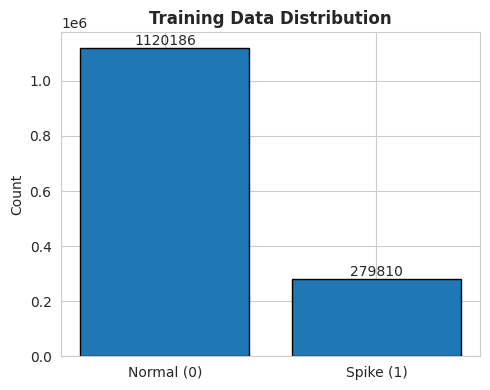

In [8]:
# IMPORTANT: Do NOT use SMOTE for this pipeline (tree models + temporal features)

print('Training Distribution (Original Data):')
print(f'  Normal (0) : {(y_train_raw == 0).sum()}')
print(f'  Spike  (1) : {(y_train_raw == 1).sum()}')

# Keep original training data
X_train = X_train_raw.copy()
y_train = y_train_raw.copy()

print('\nUsing original data (no resampling)')
print(f'  Total training samples: {len(X_train)}')

# Compute class weight for imbalance handling
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print('\nComputed scale_pos_weight:')
print(f'  scale_pos_weight = {scale_pos_weight:.4f}')

# Optional: visualize original distribution (single plot)
import matplotlib.pyplot as plt

counts = [(y_train == 0).sum(), (y_train == 1).sum()]
labels = ['Normal (0)', 'Spike (1)']

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(labels, counts, edgecolor='black')
ax.set_title('Training Data Distribution', fontweight='bold')
ax.set_ylabel('Count')

for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [9]:
import os
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

checkpoint_path = "/content/drive/MyDrive/Capstone/Project/rf_model.pkl"


if os.path.exists(checkpoint_path):
    print('Loading saved Random Forest model...')
    rf_clf = joblib.load(checkpoint_path)

else:
    print('Training Random Forest (optimized)...')

    rf_clf = RandomForestClassifier(
        n_estimators=400,
        max_depth=25,
        min_samples_split=15,
        min_samples_leaf=5,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    rf_clf.fit(X_train, y_train)

    # Save model
    joblib.dump(rf_clf, checkpoint_path)
    print('Model saved to checkpoint.')


rf_proba = rf_clf.predict_proba(X_test)[:, 1]


print("\nThreshold Tuning (Random Forest):")

best_f1 = 0
best_t = 0.5

for t in [0.5, 0.55, 0.6, 0.65, 0.7]:
    preds = (rf_proba > t).astype(int)

    p = precision_score(y_test, preds, zero_division=0)
    r = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)

    print(f"{t} → Precision={p:.3f}, Recall={r:.3f}, F1={f1:.3f}")

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"\nBest Threshold: {best_t}")


rf_preds = (rf_proba > best_t).astype(int)


rf_results = {
    'Accuracy' : accuracy_score(y_test, rf_preds),
    'Precision': precision_score(y_test, rf_preds, zero_division=0),
    'Recall'   : recall_score(y_test, rf_preds, zero_division=0),
    'F1-Score' : f1_score(y_test, rf_preds, zero_division=0),
    'ROC-AUC'  : roc_auc_score(y_test, rf_proba)
}

print('\nRandom Forest Final Results:')
for k, v in rf_results.items():
    print(f'{k:10s}: {v:.4f}')

Loading saved Random Forest model...

Threshold Tuning (Random Forest):
0.5 → Precision=0.490, Recall=0.961, F1=0.649
0.55 → Precision=0.514, Recall=0.928, F1=0.662
0.6 → Precision=0.536, Recall=0.878, F1=0.665
0.65 → Precision=0.554, Recall=0.802, F1=0.656
0.7 → Precision=0.577, Recall=0.672, F1=0.621

Best Threshold: 0.6

Random Forest Final Results:
Accuracy  : 0.8235
Precision : 0.5355
Recall    : 0.8784
F1-Score  : 0.6654
ROC-AUC   : 0.9077


In [10]:
import os
import joblib
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

checkpoint_path = "/content/drive/MyDrive/Capstone/Project/xgb_model.pkl"


scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()


if os.path.exists(checkpoint_path):
    print('Loading saved XGBoost model...')
    xgb_clf = joblib.load(checkpoint_path)

else:
    print('Training XGBoost ...')

    xgb_clf = XGBClassifier(
        n_estimators=800,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=7,
        gamma=0.3,
        reg_alpha=0.5,
        reg_lambda=1.5,
        scale_pos_weight=scale_pos_weight,
        tree_method="hist",
        grow_policy="lossguide",
        max_leaves=64,
        random_state=42,
        eval_metric='auc',
        early_stopping_rounds=50,
        n_jobs=-1,
        verbosity=0
    )

    xgb_clf.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    joblib.dump(xgb_clf, checkpoint_path)
    print('Model saved to checkpoint.')

print(f'Best iteration: {xgb_clf.best_iteration}')


xgb_proba = xgb_clf.predict_proba(X_test)[:, 1]


print("\nThreshold Tuning (XGBoost):")

best_f1 = 0
best_t = 0.5

for t in [0.5, 0.55, 0.6, 0.65, 0.7]:
    preds = (xgb_proba > t).astype(int)

    p = precision_score(y_test, preds, zero_division=0)
    r = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)

    print(f"{t} → Precision={p:.3f}, Recall={r:.3f}, F1={f1:.3f}")

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"\nBest Threshold: {best_t}")


xgb_preds = (xgb_proba > best_t).astype(int)


xgb_results = {
    'Accuracy' : accuracy_score(y_test, xgb_preds),
    'Precision': precision_score(y_test, xgb_preds, zero_division=0),
    'Recall'   : recall_score(y_test, xgb_preds, zero_division=0),
    'F1-Score' : f1_score(y_test, xgb_preds, zero_division=0),
    'ROC-AUC'  : roc_auc_score(y_test, xgb_proba)
}

print('\nXGBoost Final Results:')
for k, v in xgb_results.items():
    print(f'{k:10s}: {v:.4f}')

Loading saved XGBoost model...
Best iteration: 784

Threshold Tuning (XGBoost):
0.5 → Precision=0.547, Recall=0.962, F1=0.698
0.55 → Precision=0.551, Recall=0.945, F1=0.696
0.6 → Precision=0.554, Recall=0.926, F1=0.693
0.65 → Precision=0.557, Recall=0.903, F1=0.689
0.7 → Precision=0.561, Recall=0.875, F1=0.684

Best Threshold: 0.5

XGBoost Final Results:
Accuracy  : 0.8334
Precision : 0.5472
Recall    : 0.9621
F1-Score  : 0.6976
ROC-AUC   : 0.9173


In [15]:
import os
import joblib
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

checkpoint_path = "/content/drive/MyDrive/Capstone/Project/lgbm_model.pkl"

# COMPUTE CLASS WEIGHT
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# LOAD OR TRAIN MODEL

if os.path.exists(checkpoint_path):
    print('Loading saved LightGBM model...')
    lgbm_clf = joblib.load(checkpoint_path)

else:
    print('Training LightGBM...')

    lgbm_clf = LGBMClassifier(
        n_estimators=800,
        learning_rate=0.03,
        num_leaves=64,
        max_depth=-1,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_samples=30,
        reg_alpha=0.3,
        reg_lambda=1.2,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    lgbm_clf.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False)
        ]
    )

    joblib.dump(lgbm_clf, checkpoint_path)
    print('Model saved to checkpoint.')

print(f'Best iteration: {lgbm_clf.best_iteration_}')

# PREDICTIONS

lgbm_proba = lgbm_clf.predict_proba(X_test)[:, 1]

# THRESHOLD TUNING
print("\nThreshold Tuning (LightGBM):")

best_f1 = 0
best_t = 0.5

for t in [0.5, 0.55, 0.6, 0.65, 0.7]:
    preds = (lgbm_proba > t).astype(int)

    p = precision_score(y_test, preds, zero_division=0)
    r = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)

    print(f"{t} → Precision={p:.3f}, Recall={r:.3f}, F1={f1:.3f}")

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"\nBest Threshold: {best_t}")


# FINAL PREDICTIONS
lgbm_preds = (lgbm_proba > best_t).astype(int)


# FINAL EVALUATION

lgbm_results = {
    'Accuracy' : accuracy_score(y_test, lgbm_preds),
    'Precision': precision_score(y_test, lgbm_preds, zero_division=0),
    'Recall'   : recall_score(y_test, lgbm_preds, zero_division=0),
    'F1-Score' : f1_score(y_test, lgbm_preds, zero_division=0),
    'ROC-AUC'  : roc_auc_score(y_test, lgbm_proba)
}

print('\nLightGBM Final Results:')
for k, v in lgbm_results.items():
    print(f'{k:10s}: {v:.4f}')

Loading saved LightGBM model...
Best iteration: 47

Threshold Tuning (LightGBM):
0.5 → Precision=0.536, Recall=0.914, F1=0.676
0.55 → Precision=0.551, Recall=0.861, F1=0.672
0.6 → Precision=0.567, Recall=0.763, F1=0.651
0.65 → Precision=0.599, Recall=0.554, F1=0.576
0.7 → Precision=0.881, Recall=0.086, F1=0.156

Best Threshold: 0.5

LightGBM Final Results:
Accuracy  : 0.8247
Precision : 0.5360
Recall    : 0.9139
F1-Score  : 0.6757
ROC-AUC   : 0.9101


In [17]:
# Install (if not already) - this ensures Optuna is available
!pip install optuna -q

import os
import json
import optuna
from optuna.pruners import MedianPruner
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

file_path = "/content/drive/MyDrive/Capstone/Project/best_params.json"

best_params = None

# --- Optuna setup (moved here to ensure it's defined before potentially being used) ---
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Corrected sampling for NumPy arrays
n_train = X_train.shape[0]
sample_size = int(n_train * 0.3)
np.random.seed(42) # Ensure reproducibility
sample_indices = np.random.choice(n_train, size=sample_size, replace=False)

X_train_sample = X_train[sample_indices]
y_train_sample = y_train[sample_indices]

def objective(trial):

    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 500),
        'max_depth'        : trial.suggest_int('max_depth', 4, 8),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 3, 10),
        'gamma'            : trial.suggest_float('gamma', 0.1, 0.5),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0.1, 1.0),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1.0, 3.0),
    }

    model = XGBClassifier(
        **params,
        scale_pos_weight=scale_pos_weight,
        tree_method="hist",
        eval_metric='auc',
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=30,
        verbosity=0
    )

    model.fit(
        X_train_sample, y_train_sample,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    proba = model.predict_proba(X_val)[:, 1]

    best_f1 = 0
    for t in [0.5, 0.55, 0.6]:
        preds = (proba > t).astype(int)
        f1 = f1_score(y_val, preds, zero_division=0)
        best_f1 = max(best_f1, f1)

    return best_f1

# --- End Optuna setup ---


if os.path.exists(file_path):
    try:
        with open(file_path, "r") as f:
            best_params = json.load(f)
        print(" Best params already exist. Skipping Optuna...")
        print("\n Loaded Best Parameters:")
        for k, v in best_params.items():
            print(f"{k}: {v}")

    except json.JSONDecodeError:
        # If file exists but is empty or malformed JSON, proceed to run Optuna
        print(" Found existing 'best_params.json' but it was empty or corrupted. Re-running Optuna...")
        print(' Running Optuna.....')
        study = optuna.create_study(
            direction='maximize',
            sampler=optuna.samplers.TPESampler(seed=42),
            pruner=MedianPruner(n_startup_trials=5)
        )
        study.optimize(objective, n_trials=30, show_progress_bar=True)

        print(f'\n Best F1-Score (Validation): {study.best_value:.4f}')
        print('\n Best Parameters:')
        for k, v in study.best_params.items():
            print(f'{k}: {v}')

        # SAVE after tuning
        with open(file_path, "w") as f:
            json.dump(study.best_params, f, indent=4)
        best_params = study.best_params

else:
    # If file does not exist, run Optuna
    print(" 'best_params.json' not found. Running Optuna...")
    print(' Running Optuna.....')
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=MedianPruner(n_startup_trials=5)
    )
    study.optimize(objective, n_trials=30, show_progress_bar=True)

    print(f'\n Best F1-Score (Validation): {study.best_value:.4f}')
    print('\n Best Parameters:')
    for k, v in study.best_params.items():
        print(f'{k}: {v}')

    # SAVE after tuning
    with open(file_path, "w") as f:
        json.dump(study.best_params, f, indent=4)
    best_params = study.best_params


 Found existing 'best_params.json' but it was empty or corrupted. Re-running Optuna...
 Running Optuna.....


  0%|          | 0/30 [00:00<?, ?it/s]


 Best F1-Score (Validation): 0.6977

 Best Parameters:
n_estimators: 230
max_depth: 7
learning_rate: 0.09992800553244181
subsample: 0.9684428668297862
colsample_bytree: 0.9758114496419
min_child_weight: 7
gamma: 0.25071749648298886
reg_alpha: 0.7283496407394118
reg_lambda: 2.524338149348142


In [18]:
print(' Training FINAL Tuned XGBoost...')

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np


scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()


xgb_tuned = XGBClassifier(
    **study.best_params,
    scale_pos_weight=scale_pos_weight,   #  important
    tree_method="hist",                  #  fast
    eval_metric='auc',                   #  better than logloss
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    early_stopping_rounds=30 # Moved early_stopping_rounds to the constructor
)


xgb_tuned.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    # Removed early_stopping_rounds from fit method
    verbose=False
)

print(f"Best Iterations: {xgb_tuned.best_iteration}")


proba = xgb_tuned.predict_proba(X_test)[:, 1]


best_f1 = 0
best_threshold = 0.5

for t in np.arange(0.4, 0.7, 0.05):
    preds = (proba > t).astype(int)
    f1 = f1_score(y_test, preds, zero_division=0)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

# Final predictions
final_preds = (proba > best_threshold).astype(int)


xgb_tuned_results = {
    'Accuracy' : accuracy_score(y_test, final_preds),
    'Precision': precision_score(y_test, final_preds, zero_division=0),
    'Recall'   : recall_score(y_test, final_preds, zero_division=0),
    'F1-Score' : f1_score(y_test, final_preds, zero_division=0),
    'ROC-AUC'  : roc_auc_score(y_test, proba)
}


print('\n Tuned XGBoost Results :')
print(f" Best Threshold: {best_threshold:.2f}")

for k, v in xgb_tuned_results.items():
    print(f'{k:10s}: {v:.4f}')

 Training FINAL Tuned XGBoost...
Best Iterations: 225

 Tuned XGBoost Results :
 Best Threshold: 0.50
Accuracy  : 0.8336
Precision : 0.5474
Recall    : 0.9647
F1-Score  : 0.6985
ROC-AUC   : 0.9175


In [21]:
print(' Training Soft Voting Ensemble...')

from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
from xgboost import XGBClassifier # Import XGBClassifier to clone

# Create a clone of xgb_tuned and disable early stopping for the ensemble
xgb_tuned_for_ensemble = XGBClassifier(**xgb_tuned.get_params())
xgb_tuned_for_ensemble.set_params(early_stopping_rounds=None, verbosity=0) # Disable early stopping

ensemble = VotingClassifier(
    estimators=[
        ('rf',   rf_clf),
        ('xgb',  xgb_tuned_for_ensemble), # Use the modified XGBoost model
        ('lgbm', lgbm_clf)
    ],
    voting='soft',
    weights=[1, 2, 2],   #  give more importance to boosting models
    n_jobs=-1
)

ensemble.fit(X_train, y_train)


proba = ensemble.predict_proba(X_test)[:, 1]


best_f1 = 0
best_threshold = 0.5

for t in np.arange(0.4, 0.7, 0.05):
    preds = (proba > t).astype(int)
    f1 = f1_score(y_test, preds, zero_division=0)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

final_preds = (proba > best_threshold).astype(int)


ens_results = {
    'Accuracy' : accuracy_score(y_test, final_preds),
    'Precision': precision_score(y_test, final_preds, zero_division=0),
    'Recall'   : recall_score(y_test, final_preds, zero_division=0),
    'F1-Score' : f1_score(y_test, final_preds, zero_division=0),
    'ROC-AUC'  : roc_auc_score(y_test, proba)
}


print('\n Ensemble Results (Optimized):')
print(f" Best Threshold: {best_threshold:.2f}")

for k, v in ens_results.items():
    print(f'{k:10s}: {v:.4f}')

 Training Soft Voting Ensemble...

 Ensemble Results (Optimized):
 Best Threshold: 0.50
Accuracy  : 0.8331
Precision : 0.5464
Recall    : 0.9692
F1-Score  : 0.6988
ROC-AUC   : 0.9176


 MODEL COMPARISON — ALL MODELS (Test Set)
                 Accuracy  Precision  Recall  F1-Score  ROC-AUC
Random Forest      0.8235     0.5355  0.8784    0.6654   0.9077
XGBoost            0.8334     0.5472  0.9621    0.6976   0.9173
XGBoost (Tuned)    0.8336     0.5474  0.9647    0.6985   0.9175
LightGBM           0.8247     0.5360  0.9139    0.6757   0.9101
Ensemble           0.8331     0.5464  0.9692    0.6988   0.9176

 Best Model by F1-Score: Ensemble  (0.6988)


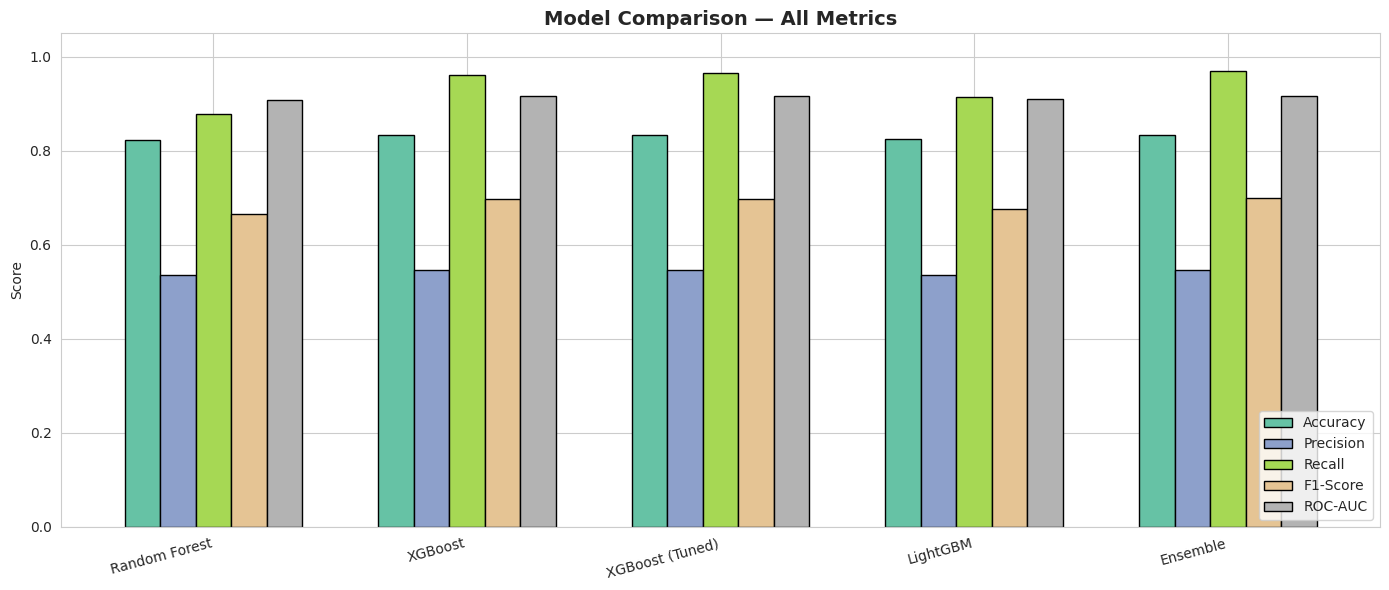

In [23]:
# Build comparison table
comparison = pd.DataFrame({
    'Random Forest'   : rf_results,
    'XGBoost'         : xgb_results,
    'XGBoost (Tuned)' : xgb_tuned_results,
    'LightGBM'        : lgbm_results,
    'Ensemble'        : ens_results
}).T

print('=' * 70)
print(' MODEL COMPARISON — ALL MODELS (Test Set)')
print('=' * 70)
print(comparison.round(4).to_string())
print('=' * 70)

# Find best model
best_model = comparison['F1-Score'].idxmax()
best_f1    = comparison['F1-Score'].max()
print(f'\n Best Model by F1-Score: {best_model}  ({best_f1:.4f})')

# Bar chart comparison
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
ax = comparison[metrics_to_plot].plot(
    kind='bar', figsize=(14, 6),
    colormap='Set2', edgecolor='black', width=0.7
)
plt.title('Model Comparison — All Metrics', fontweight='bold', fontsize=14)
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=15, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

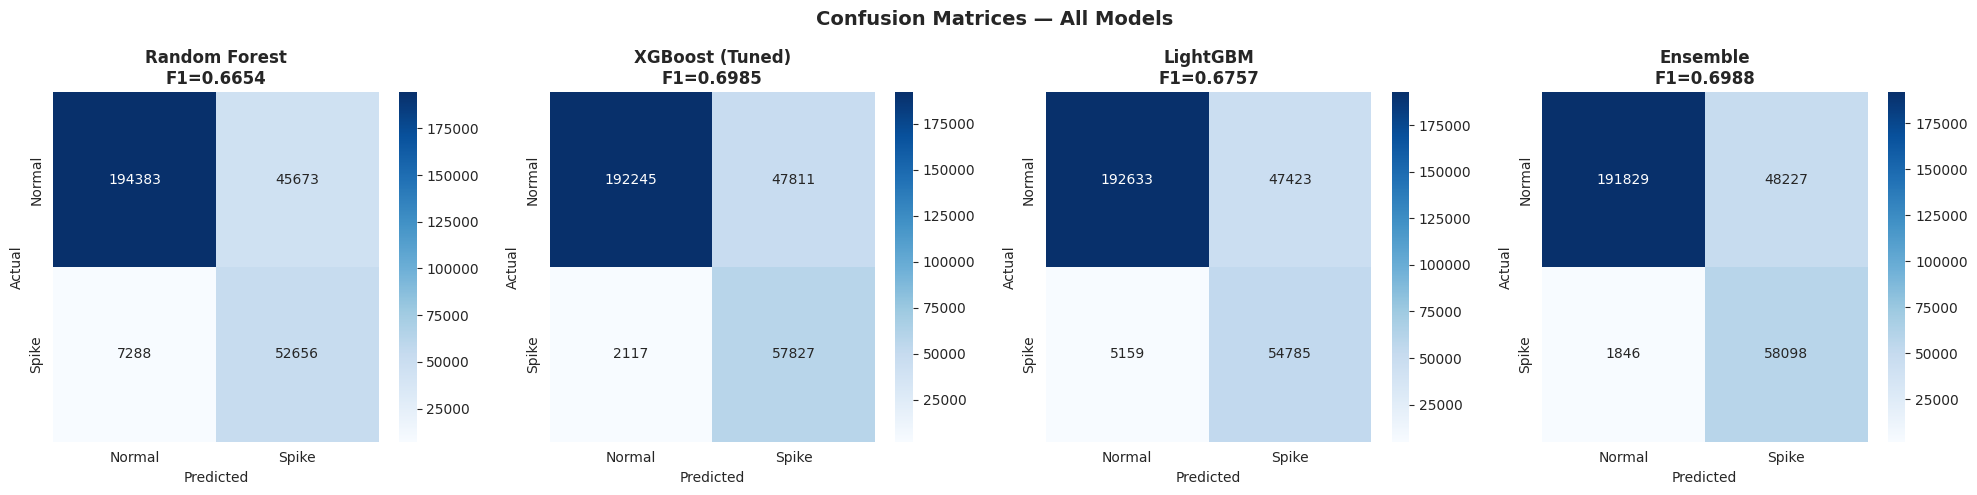

In [26]:
proba_tuned_xgb = xgb_tuned.predict_proba(X_test)[:, 1]
xgb_tuned_preds = (proba_tuned_xgb > 0.5).astype(int)

# Define ens_preds using the final_preds from the ensemble model
ens_preds = final_preds

models_preds = {
    'Random Forest'   : rf_preds,
    'XGBoost (Tuned)' : xgb_tuned_preds,
    'LightGBM'        : lgbm_preds,
    'Ensemble'        : ens_preds
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, preds) in zip(axes, models_preds.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Spike'],
                yticklabels=['Normal', 'Spike'])
    f1 = f1_score(y_test, preds, zero_division=0)
    ax.set_title(f'{name}\nF1={f1:.4f}', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — All Models', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrices_all.png', dpi=120, bbox_inches='tight')
plt.show()

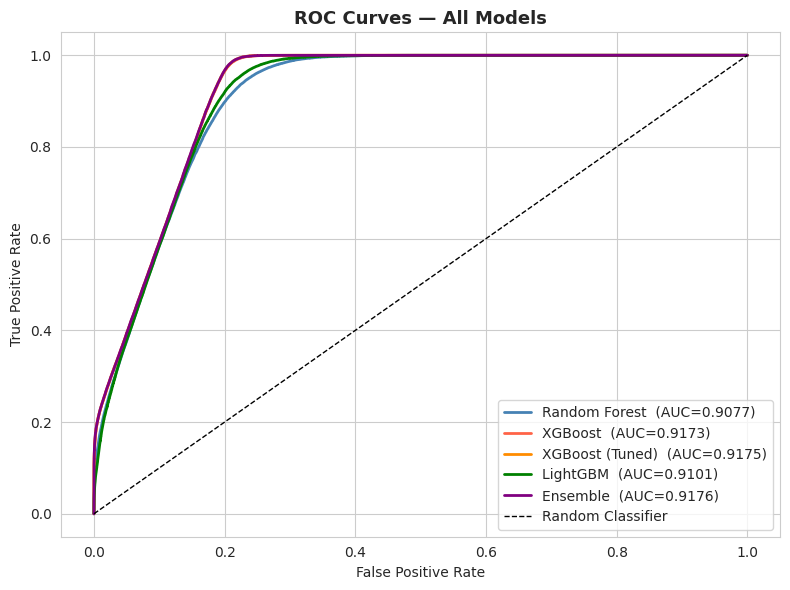

In [29]:
models_proba = {
    'Random Forest'   : rf_proba,
    'XGBoost'         : xgb_proba,
    'XGBoost (Tuned)' : proba_tuned_xgb,
    'LightGBM'        : lgbm_proba,
    'Ensemble'        : proba
}

colors = ['steelblue', 'tomato', 'darkorange', 'green', 'purple']

plt.figure(figsize=(8, 6))
for (name, proba_val), color in zip(models_proba.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba_val)
    auc_val = roc_auc_score(y_test, proba_val)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name}  (AUC={auc_val:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.title('ROC Curves — All Models', fontweight='bold', fontsize=13)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves_all.png', dpi=120, bbox_inches='tight')
plt.show()

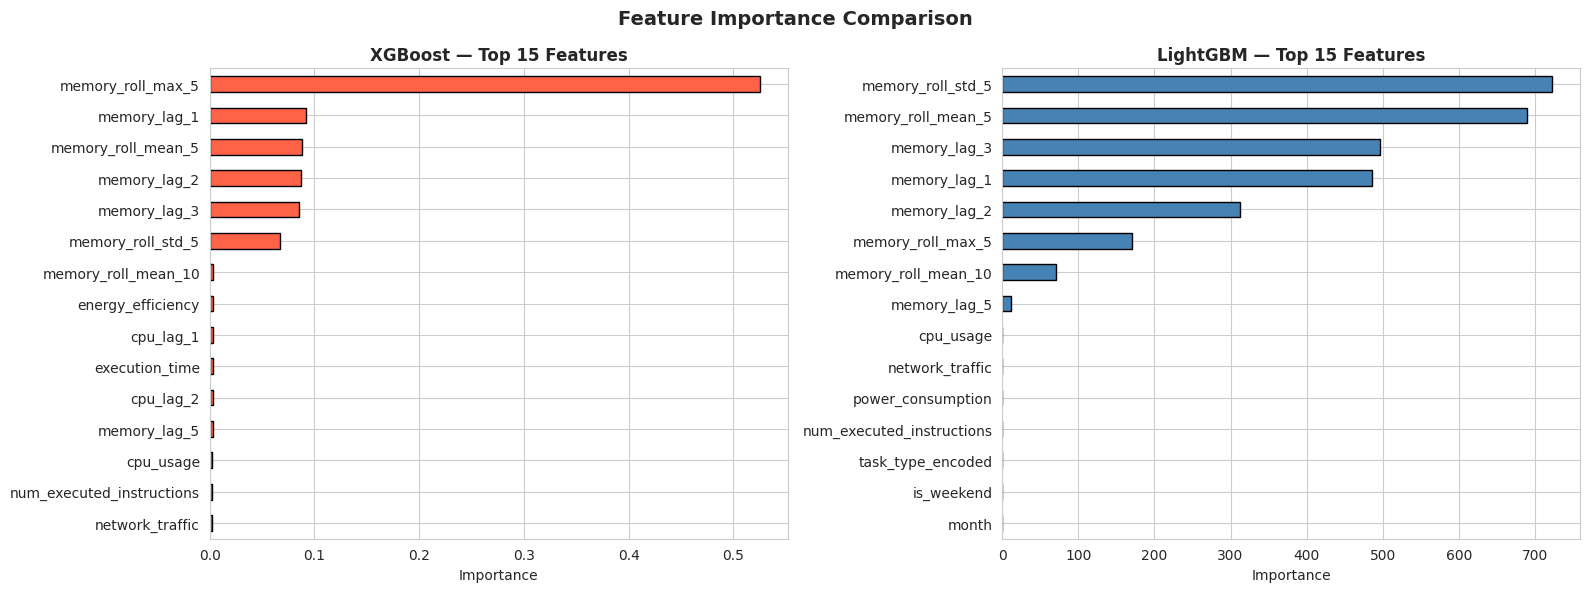

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost feature importance
xgb_imp = pd.Series(xgb_tuned.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)
xgb_imp.plot(kind='barh', ax=axes[0], color='tomato', edgecolor='black')
axes[0].set_title('XGBoost — Top 15 Features', fontweight='bold')
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()

# LightGBM feature importance
lgbm_imp = pd.Series(lgbm_clf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)
lgbm_imp.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('LightGBM — Top 15 Features', fontweight='bold')
axes[1].set_xlabel('Importance')
axes[1].invert_yaxis()

plt.suptitle('Feature Importance Comparison', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [31]:
# Pick the best model based on F1-Score from comparison table
best_preds_map = {
    'Random Forest'   : rf_preds,
    'XGBoost'         : xgb_preds,
    'XGBoost (Tuned)' : xgb_tuned_preds,
    'LightGBM'        : lgbm_preds,
    'Ensemble'        : ens_preds
}

best_final_preds = best_preds_map[best_model]

print('=' * 55)
print(f' FINAL BEST MODEL: {best_model}')
print('=' * 55)
print(classification_report(
    y_test, best_final_preds,
    target_names=['Normal (0)', 'Spike (1)']
))

# Improvement summary vs baseline RF
print('\n Improvement Over Baseline Random Forest:')
for metric in ['Accuracy', 'F1-Score', 'ROC-AUC']:
    baseline = rf_results[metric]
    best     = comparison.loc[best_model, metric]
    delta    = best - baseline
    print(f'   {metric:10s}: {baseline:.4f} → {best:.4f}  ({delta:+.4f})')

 FINAL BEST MODEL: Ensemble
              precision    recall  f1-score   support

  Normal (0)       0.99      0.80      0.88    240056
   Spike (1)       0.55      0.97      0.70     59944

    accuracy                           0.83    300000
   macro avg       0.77      0.88      0.79    300000
weighted avg       0.90      0.83      0.85    300000


 Improvement Over Baseline Random Forest:
   Accuracy  : 0.8235 → 0.8331  (+0.0096)
   F1-Score  : 0.6654 → 0.6988  (+0.0335)
   ROC-AUC   : 0.9077 → 0.9176  (+0.0099)


In [32]:
import pickle

best_model_obj_map = {
    'Random Forest'   : rf_clf,
    'XGBoost'         : xgb_clf,
    'XGBoost (Tuned)' : xgb_tuned,
    'LightGBM'        : lgbm_clf,
    'Ensemble'        : ensemble
}

best_model_obj = best_model_obj_map[best_model]

# Save best model
model_save_path = os.path.join(PROJECT_FOLDER, 'best_model_improved.pkl')
with open(model_save_path, 'wb') as f:
    pickle.dump(best_model_obj, f)
print(f' Best model saved: {model_save_path}')

# Save feature columns
feat_save_path = os.path.join(PROJECT_FOLDER, 'feature_cols_improved.pkl')
with open(feat_save_path, 'wb') as f:
    pickle.dump(feature_cols, f)
print(f' Feature columns saved: {feat_save_path}')

# Save comparison table as CSV
csv_path = os.path.join(PROJECT_FOLDER, 'model_comparison_results.csv')
comparison.round(4).to_csv(csv_path)
print(f' Comparison table saved: {csv_path}')

print('\n All files saved to Google Drive!')

 Best model saved: /content/drive/MyDrive/Capstone/Project/best_model_improved.pkl
 Feature columns saved: /content/drive/MyDrive/Capstone/Project/feature_cols_improved.pkl
 Comparison table saved: /content/drive/MyDrive/Capstone/Project/model_comparison_results.csv

 All files saved to Google Drive!
